In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [83]:
df = pd.read_excel(r"C:\Users\singh\Downloads\561 file for ML Model.xlsx")

print("Dataset Shape:", df.shape)

print("\nDataset Columns:")
print(df.columns)

Dataset Shape: (560, 30)

Dataset Columns:
Index(['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti',
       'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*',
       'UTS (MPa)', 'YS (MPa)', 'Total Elongation (%)', 'Engg. Strain',
       'n-Value'],
      dtype='str')


In [84]:
df = df.drop_duplicates()

df = df.replace([np.inf, -np.inf], np.nan)

df = df.fillna(df.median(numeric_only=True))

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (560, 30)


In [85]:
X = df.drop(columns=[
    "UTS (MPa)",
    "YS (MPa)"
])

y = df[
    [
        "Total Elongation (%)",
        "Engg. Strain",
        "n-Value"
    ]
]

y = df[target_columns]

In [86]:
X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("Training Samples   :", X_train.shape[0])
print("Validation Samples :", X_validation.shape[0])

Training Samples   : 448
Validation Samples : 112


In [87]:
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_validation_scaled = X_scaler.transform(X_validation)

y_train_scaled = y_scaler.fit_transform(y_train)

y_validation_scaled = y_scaler.transform(y_validation)

In [88]:
perceptron = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=3000,
    random_state=42
)

In [89]:
print(perceptron)

MLPRegressor(alpha=0.001, hidden_layer_sizes=(128, 64, 32), max_iter=3000,
             random_state=42)


In [90]:
print(X.columns)
print(y.columns)

Index(['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti',
       'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*',
       'Total Elongation (%)', 'Engg. Strain', 'n-Value'],
      dtype='str')
Index(['Total Elongation (%)', 'Engg. Strain', 'n-Value'], dtype='str')


In [91]:
epochs = 500

training_loss = []
validation_loss = []

perceptron = MLPRegressor(
    hidden_layer_sizes=(128,64,32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=1,
    warm_start=True,
    random_state=42
)

for epoch in range(epochs):

    perceptron.partial_fit(
        X_train_scaled,
        y_train_scaled
    )

    train_pred = perceptron.predict(
        X_train_scaled
    )

    val_pred = perceptron.predict(
        X_validation_scaled
    )

    train_mse = mean_squared_error(
        y_train_scaled,
        train_pred
    )

    val_mse = mean_squared_error(
        y_validation_scaled,
        val_pred
    )

    training_loss.append(train_mse)
    validation_loss.append(val_mse)

    if (epoch + 1) % 50 == 0:

        print(
            "Epoch:", epoch + 1,
            "| Training Loss:", train_mse,
            "| Validation Loss:", val_mse
        )
        


Epoch: 50 | Training Loss: 0.0030887083999943618 | Validation Loss: 0.014171274097426871
Epoch: 100 | Training Loss: 0.0009774188203078374 | Validation Loss: 0.00964602662163932
Epoch: 150 | Training Loss: 0.0005048366391063964 | Validation Loss: 0.008238765024740026
Epoch: 200 | Training Loss: 0.0003089269609244405 | Validation Loss: 0.00739656293320476
Epoch: 250 | Training Loss: 0.00020297017259812204 | Validation Loss: 0.006818353263175181
Epoch: 300 | Training Loss: 0.0001415223072677533 | Validation Loss: 0.006462622775157295
Epoch: 350 | Training Loss: 0.00010173906082137824 | Validation Loss: 0.0062141259066971904
Epoch: 400 | Training Loss: 7.485473598500222e-05 | Validation Loss: 0.006002076580511139
Epoch: 450 | Training Loss: 5.6696132082240375e-05 | Validation Loss: 0.00583410214173517
Epoch: 500 | Training Loss: 4.370470041841159e-05 | Validation Loss: 0.005686600389863942


In [92]:
print(len(training_loss))
print(len(validation_loss))

print(training_loss[:10])
print(validation_loss[:10])

500
500
[0.9277594034339388, 0.7600944938263865, 0.6078881375535253, 0.46392196587451767, 0.3386536296565743, 0.23703030747823672, 0.16354376205894786, 0.12133238760001765, 0.1023910595431463, 0.08997655244012732]
[1.0537474458787697, 0.8787359351816418, 0.7120491830679345, 0.5500561377229043, 0.4078232432610836, 0.29074872469289387, 0.20272016274842064, 0.14490977444222383, 0.1134003565892016, 0.09644847877766521]


In [93]:
print(min(training_loss), max(training_loss))
print(min(validation_loss), max(validation_loss))

4.370470041841159e-05 0.9277594034339388
0.005686600389863942 1.0537474458787697


In [94]:

y_pred_scaled = perceptron.predict(
    X_validation_scaled
)


# Convert scaled prediction to original values

y_pred = y_scaler.inverse_transform(
    y_pred_scaled
)

In [95]:
mse = mean_squared_error(
    y_validation,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_validation,
    y_pred
)

r2 = r2_score(
    y_validation,
    y_pred
)

In [96]:
print("\n========== PERCEPTRON REGRESSION RESULT ==========")

print("MSE      :", mse)

print("RMSE     :", rmse)

print("MAE      :", mae)

print("R2 Score :", r2)


========== PERCEPTRON REGRESSION RESULT ==========
MSE      : 0.09337739610574525
RMSE     : 0.3055771524602997
MAE      : 0.11689395645223383
R2 Score : 0.994725162047961


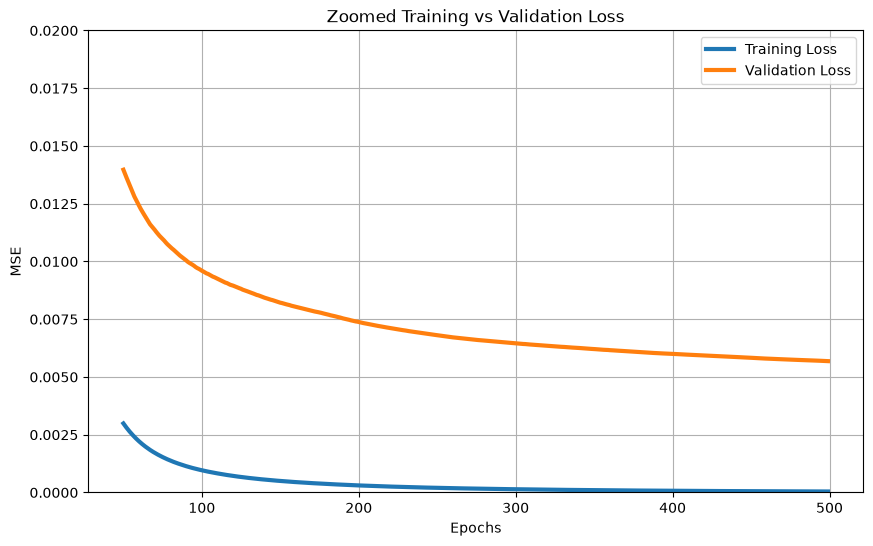

In [97]:
start = 50

plt.figure(figsize=(10,6))

plt.plot(
    range(start, epochs),
    training_loss[start:],
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    range(start, epochs),
    validation_loss[start:],
    linewidth=3,
    label="Validation Loss"
)

plt.ylim(0,0.02)

plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.title("Zoomed Training vs Validation Loss")

plt.grid(True)
plt.legend()

plt.show()

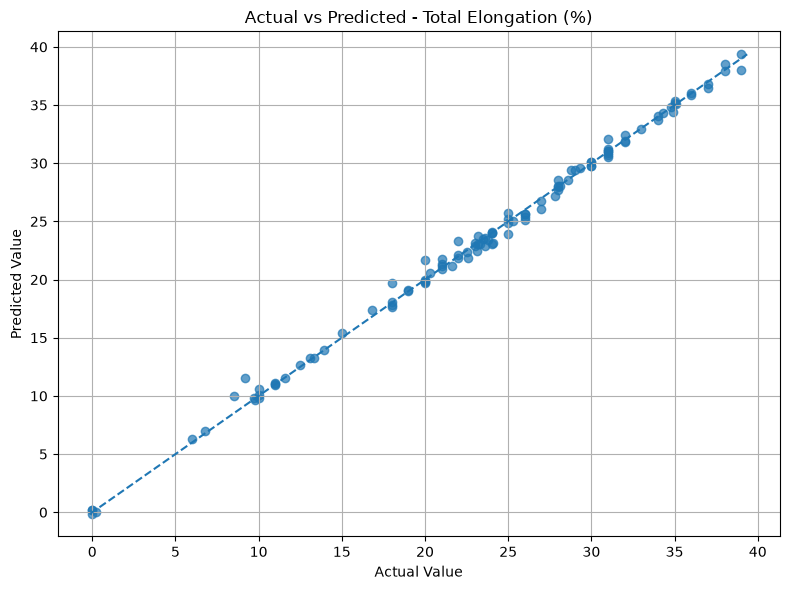

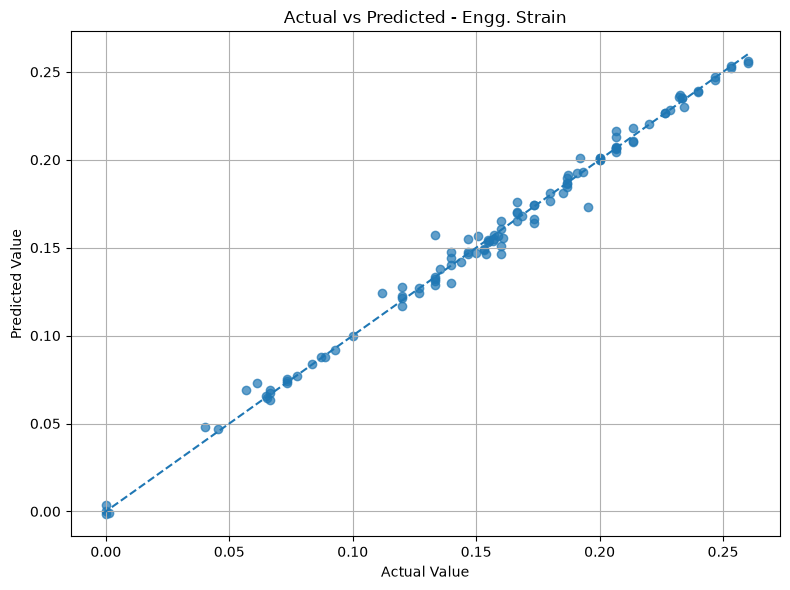

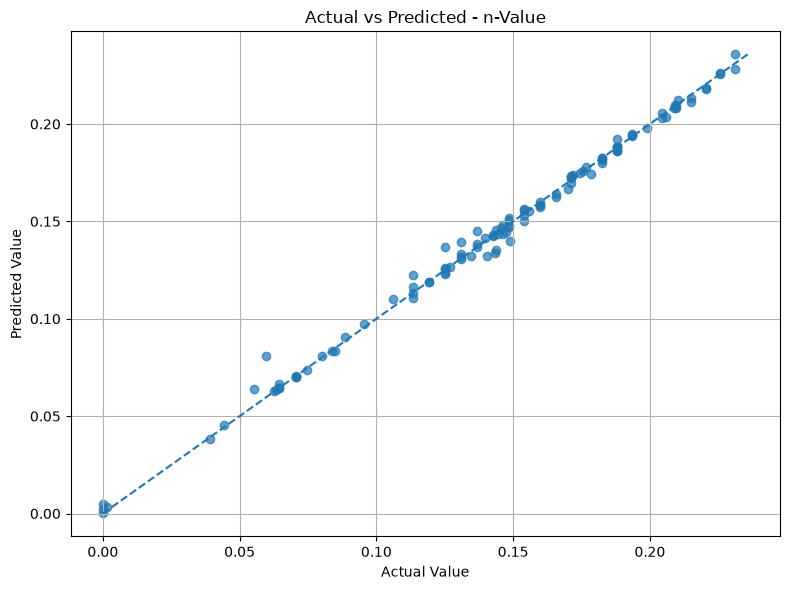

In [98]:
target_columns = [
    "Total Elongation (%)",
    "Engg. Strain",
    "n-Value"
]
for i, column in enumerate(target_columns):

    plt.figure(figsize=(8, 6))


    plt.scatter(
        y_validation.iloc[:, i],
        y_pred[:, i],
        alpha=0.7
    )


    minimum_value = min(
        y_validation.iloc[:, i].min(),
        y_pred[:, i].min()
    )


    maximum_value = max(
        y_validation.iloc[:, i].max(),
        y_pred[:, i].max()
    )


    plt.plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        linestyle="--"
    )


    plt.xlabel("Actual Value")

    plt.ylabel("Predicted Value")

    plt.title(
        f"Actual vs Predicted - {column}"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.show()

In [99]:
prediction_df = pd.DataFrame()


for i, column in enumerate(target_columns):

    prediction_df[
        "Actual " + column
    ] = y_validation.iloc[:, i].values


    prediction_df[
        "Predicted " + column
    ] = y_pred[:, i]


print(
    "\n========== ACTUAL VS PREDICTED VALUES =========="
)


print(
    prediction_df.head(10)
)


========== ACTUAL VS PREDICTED VALUES ==========
   Actual Total Elongation (%)  Predicted Total Elongation (%)  \
0                        35.00                       35.355462   
1                        29.00                       29.396784   
2                        20.00                       19.860576   
3                        23.20                       23.728419   
4                        36.00                       35.896068   
5                        21.00                       21.154062   
6                        24.00                       24.023617   
7                        11.00                       10.987454   
8                        11.00                       11.137796   
9                         0.21                        0.061212   

   Actual Engg. Strain  Predicted Engg. Strain  Actual n-Value  \
0             0.233333                0.235064        0.209721   
1             0.193333                0.192788        0.176751   
2             0.133333   

In [100]:
prediction_df.to_excel(
    "MLP_Regressor_Predictions.xlsx",
    index=False
)


print(
    "\nPredictions saved successfully."
)


Predictions saved successfully.


In [101]:
print("Minimum Validation Loss :", min(validation_loss))
print(
    "Minimum Epoch :",
    np.argmin(validation_loss) + 1
)


Minimum Validation Loss : 0.005686600389863942
Minimum Epoch : 500


In [102]:
print(X.columns.tolist())

['C', 'Mn', 'Si', 'Al', 'B', 'N', 'Ca', 'P', 'Ni', 'S', 'Cr', 'Mo', 'Ti', 'V', 'Nb', 'Ni.1', 'Zn', 'Cu', 'Sn', 'W', 'Co', 'Zr', 'O', 'Mg', 'Ti*', 'Total Elongation (%)', 'Engg. Strain', 'n-Value']
